## Pendahuluan

Notebook ini menyajikan analisis sentimen ulasan aplikasi Google Play 'com.rio.ahok' dengan menerapkan langkah-langkah evaluasi model Natural Language Processing (NLP) yang komprehensif, sesuai dengan persyaratan:

1.  **Scraping Data Mandiri:** Mengambil data ulasan langsung dari Google Play Store.
2.  **Dataset Minimal 100 Data:** Target 500 ulasan.
3.  **Minimal 4-6 Halaman:** Struktur notebook dibagi menjadi beberapa bagian utama.
4.  **Evaluasi dengan 5 Langkah:**
    *   K-Fold Cross Validation (5-Fold).
    *   Pemilihan Hyperparameter dengan Nested CV.
    *   Perhitungan Precision, Recall, F1, dan Confusion Matrix.
    *   Analisis Kesalahan (Error Analysis) pada 50 sampel.
    *   Minimal 2 Uji CheckList (MFT dan INV Test).

In [ ]:
# Core
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Install Sastrawi
!pip install Sastrawi

# install google-play-scraper
!pip install google-play-scraper

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Download resource NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Machine Learning
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Evaluasi
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Visualisasi (opsional)
import matplotlib.pyplot as plt
import seaborn as sns

# Save model
import joblib

## 1. Proses Pengambilan Data (Scraping)

Bagian ini melakukan scraping ulasan dari Google Play Store untuk aplikasi `com.rio.ahok` (game Basuki Tjahaja Purnama). Data diambil sebanyak 500 ulasan terbaru dalam Bahasa Indonesia dan disimpan ke dalam file CSV mentah.

In [ ]:
from google_play_scraper import Sort, reviews
import pandas as pd

# 1. Konfigurasi
app_id = 'com.rio.ahok'
jumlah_data = 500

print("Sedang mengambil data...")

# 2. Scraping
result, _ = reviews(
    app_id,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=jumlah_data
)

# 3. Convert ke DataFrame
df_raw = pd.DataFrame(result)

# 4. Ambil kolom penting + rename biar clean
df_raw = df_raw[['content', 'score']]
df_raw.columns = ['ulasan', 'rating']

# 5. Bersihkan data kosong
df_raw.dropna(inplace=True)

# hapus ulasan kosong / whitespace
df_raw = df_raw[df_raw['ulasan'].str.strip() != ""]

# 6. Hapus duplikasi
df_raw.drop_duplicates(subset='ulasan', inplace=True)

# 7. Reset index biar rapi
df_raw.reset_index(drop=True, inplace=True)

# 8. Simpan ke CSV
df_raw.to_csv('ulasan_mentah.csv', index=False)

print(f"Selesai! Total data bersih: {len(df_raw)}")
print(df_raw.head())

Sedang mengambil data...
Selesai! Total data bersih: 484
                                              ulasan  rating
0                                    Dev nya gabut 🗿       5
1  gak ad Gibran Ama Bahlil tambahin dong bg sama...       5
2               agak bagus karena karakternya kurang       4
3  seru banget tapi update game nya jadi lebih me...       5
4  game nya seru tapi saat kita serang lawan nya ...       4


## 2. Pra-pemrosesan Teks Ulasan

Langkah ini meliputi:
-   Memuat data ulasan mentah.
-   Memberikan label sentimen (negatif, netral, positif) berdasarkan skor ulasan.
-   Mendefinisikan kamus normalisasi slang/singkatan.
-   Menerapkan serangkaian fungsi pra-pemrosesan teks (case folding, hapus URL, mention, hashtag, emoji, angka, tanda baca, karakter berulang, normalisasi spasi, normalisasi slang, tokenisasi, hapus stopword, dan stemming).
-   Menyimpan data ulasan yang sudah bersih ke `ulasan_bersih.csv`.

In [ ]:
# Load data
df = pd.read_csv('ulasan_mentah.csv')

print(f"Data awal: {df.shape[0]} baris")
print(df['rating'].value_counts().sort_index())

# Validasi data
df.dropna(subset=['ulasan', 'rating'], inplace=True)
df = df[df['rating'].between(1, 5)]

print(f"\nData setelah cleaning: {df.shape[0]} baris")

# Label sentimen
def label_sentimen(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

df['sentimen'] = df['rating'].apply(label_sentimen)

print("\nDistribusi sentimen:")
print(df['sentimen'].value_counts())

print("\nPersentase sentimen:")
print(df['sentimen'].value_counts(normalize=True) * 100)

Data awal: 484 baris
rating
1     91
2     16
3     20
4     37
5    320
Name: count, dtype: int64

Data setelah cleaning: 484 baris

Distribusi sentimen:
sentimen
positif    357
negatif    107
netral      20
Name: count, dtype: int64

Persentase sentimen:
sentimen
positif    73.760331
negatif    22.107438
netral      4.132231
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Load data
df = pd.read_csv('ulasan_mentah.csv')

# Label sentimen
def label_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

df['label'] = df['rating'].apply(label_sentiment)

# Kamus slang
kamus_slang = {
    'yg': 'yang','dgn': 'dengan','dg': 'dengan','utk': 'untuk',
    'krn': 'karena','karna': 'karena','klo': 'kalau','klu': 'kalau',
    'kl': 'kalau','gak': 'tidak','ga': 'tidak','gk': 'tidak',
    'ngga': 'tidak','nggak': 'tidak','enggak': 'tidak','kagak': 'tidak',
    'tdk': 'tidak','tak': 'tidak','tp': 'tapi','tpi': 'tapi',
    'ttg': 'tentang','sm': 'sama','sama2': 'sama sama',
    'bgt': 'banget','bngt': 'banget','bget': 'banget',
    'jg': 'juga','juga2': 'juga juga','jd': 'jadi','jdi': 'jadi',
    'sdh': 'sudah','udh': 'sudah','udah': 'sudah','dah': 'sudah',
    'blm': 'belum','blum': 'belum','msh': 'masih',
    'emg': 'memang','emang': 'memang','mmg': 'memang',
    'gw': 'saya','gue': 'saya','aku': 'saya','w': 'saya',
    'lo': 'kamu','lu': 'kamu','elo': 'kamu',
    'lg': 'lagi','lg2': 'lagi lagi','lgi': 'lagi',
    'bs': 'bisa','bsa': 'bisa','biss': 'bisa',
    'hrs': 'harus','hrus': 'harus',
    'mw': 'mau','lbh': 'lebih',
    'aja': 'saja','aj': 'saja',
    'sih': '','deh': '','dong': '','nih': '','lah': '','kan': '',
    'ndk': 'tidak','ndak': 'tidak','nda': 'tidak',
    'mk': 'maka','dr': 'dari','pd': 'pada',
    'sy': 'saya','sya': 'saya',
    'tlg': 'tolong','tlong': 'tolong',
    'mksh': 'terima kasih','makasih': 'terima kasih','thx': 'terima kasih',
    'thanks': 'terima kasih','tq': 'terima kasih',
    'ok': 'oke','okey': 'oke',
    'iyaa': 'iya','iyaaa': 'iya',
    'gem': 'game','gim': 'game',
    'muak': 'bosan',
    'donlod': 'download','dwnld': 'download',
    'burik': 'jelek','ancur': 'rusak',
    'mantap': 'bagus','mantul': 'bagus','keren': 'bagus',
    'sadis': 'hebat','gokil': 'hebat','gilak': 'gila',
    'wkwk': '','wkwkwk': '','haha': '','hehe': '','hihi': '',
    'woi': '','eh': ''
}

# Stopword
stopwords = set(['yang','dan','di','ke','dari','ini','itu','untuk','dengan','pada','adalah'])

# Stemmer
stemmer = StemmerFactory().create_stemmer()

# Preprocessing
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'(.)\1+', r'\1\1', text)

    tokens = text.split()
    tokens = [kamus_slang.get(w, w) for w in tokens]
    tokens = [w for w in tokens if w not in stopwords]
    tokens = [stemmer.stem(w) for w in tokens]

    return ' '.join(tokens)

# Apply preprocessing
df['clean_text'] = df['ulasan'].astype(str).apply(preprocess)

# Save
df[['clean_text','label']].to_csv('ulasan_bersih.csv', index=False)

print("Preprocessing selesai")
print(df.head())

Preprocessing selesai
                                              ulasan  rating    label  \
0                                    Dev nya gabut 🗿       5  positif   
1  gak ad Gibran Ama Bahlil tambahin dong bg sama...       5  positif   
2               agak bagus karena karakternya kurang       4  positif   
3  seru banget tapi update game nya jadi lebih me...       5  positif   
4  game nya seru tapi saat kita serang lawan nya ...       4  positif   

                                          clean_text  
0                                     dev nya gabut   
1  tidak ad gibran ama bahlil tambahin  bg sama s...  
2                  agak bagus karena karakter kurang  
3  seru banget tapi update game nya jadi lebih ta...  
4  game nya seru tapi saat kita serang lawan nya ...  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('ulasan_bersih.csv')
df = df.dropna(subset=['clean_text', 'label'])
df = df[df['clean_text'].astype(str).str.strip() != ''].reset_index(drop=True)

X = df['clean_text']
y = df['label']

print(f"Total data: {len(df)}")
print(y.value_counts())

# Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1_macro': make_scorer(f1_score, average='macro'),
    'f1_weighted': make_scorer(f1_score, average='weighted'),
}

cv_results = cross_validate(
    pipeline, X, y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

# Hasil
print("\nHasil 5-Fold CV:")
for metric, key in [
    ('Accuracy', 'test_accuracy'),
    ('F1 Macro', 'test_f1_macro'),
    ('F1 Weighted', 'test_f1_weighted'),
]:
    scores = cv_results[key]
    print(f"{metric:15s}: {scores.mean():.4f} ± {scores.std():.4f}")

# Train final
pipeline.fit(X, y)
joblib.dump(pipeline, 'model_pipeline.pkl')

print("\nModel disimpan.")

Total data: 478
label
positif    352
negatif    107
netral      19
Name: count, dtype: int64

Hasil 5-Fold CV:
Accuracy       : 0.7132 ± 0.0388
F1 Macro       : 0.4595 ± 0.0670
F1 Weighted    : 0.7164 ± 0.0320

Model disimpan.


In [ ]:
# Load data

df = pd.read_csv('ulasan_bersih.csv')
df = df.dropna(subset=['clean_text', 'label'])
df = df[df['clean_text'].astype(str).str.strip() != ''].reset_index(drop=True)

X = df['clean_text'].values
y = df['label'].values


# Pipeline & parameter

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, min_df=2)),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [3000, 5000],
    'clf__C': [0.1, 1.0, 10.0],
}


# Nested CV

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scorer = make_scorer(f1_score, average='macro')

print("Running nested CV...\n")

nested_scores = []
best_params_per_fold = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=inner_cv,
        scoring=scorer,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    score = f1_score(y_test, y_pred, average='macro')

    nested_scores.append(score)
    best_params_per_fold.append(grid.best_params_)

    print(f"Fold {fold}: F1 = {score:.4f} | Params: {grid.best_params_}")

nested_scores = np.array(nested_scores)


# Hasil

print("\n=== Nested CV Result ===")
print(f"F1 Macro: {nested_scores.mean():.3f} ± {nested_scores.std():.3f}")
print(f"Per fold: {[round(s,4) for s in nested_scores]}")


# Final model

print("\nTraining final model...")

final_grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=inner_cv,
    scoring=scorer,
    n_jobs=-1,
    refit=True
)

final_grid.fit(X, y)

print(f"Best params: {final_grid.best_params_}")
print(f"Best CV score: {final_grid.best_score_:.4f}")

joblib.dump(final_grid.best_estimator_, 'model_best.pkl')

pd.DataFrame({
    'best_params': [str(final_grid.best_params_)]
}).to_csv('best_params.csv', index=False)

print("Model saved")

Running nested CV...

Fold 1: F1 = 0.5610 | Params: {'clf__C': 0.1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Fold 2: F1 = 0.4910 | Params: {'clf__C': 0.1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Fold 3: F1 = 0.4515 | Params: {'clf__C': 0.1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Fold 4: F1 = 0.4002 | Params: {'clf__C': 0.1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Fold 5: F1 = 0.3917 | Params: {'clf__C': 0.1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}

=== Nested CV Result ===
F1 Macro: 0.459 ± 0.062
Per fold: [np.float64(0.561), np.float64(0.491), np.float64(0.4515), np.float64(0.4002), np.float64(0.3917)]

Training final model...
Best params: {'clf__C': 0.1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Best CV score: nan
Model saved


PRECISION, RECALL, F1
              precision    recall  f1-score   support

     negatif       0.47      0.47      0.47       107
      netral       0.08      0.16      0.10        19
     positif       0.82      0.78      0.80       352

    accuracy                           0.68       478
   macro avg       0.46      0.47      0.46       478
weighted avg       0.71      0.68      0.70       478



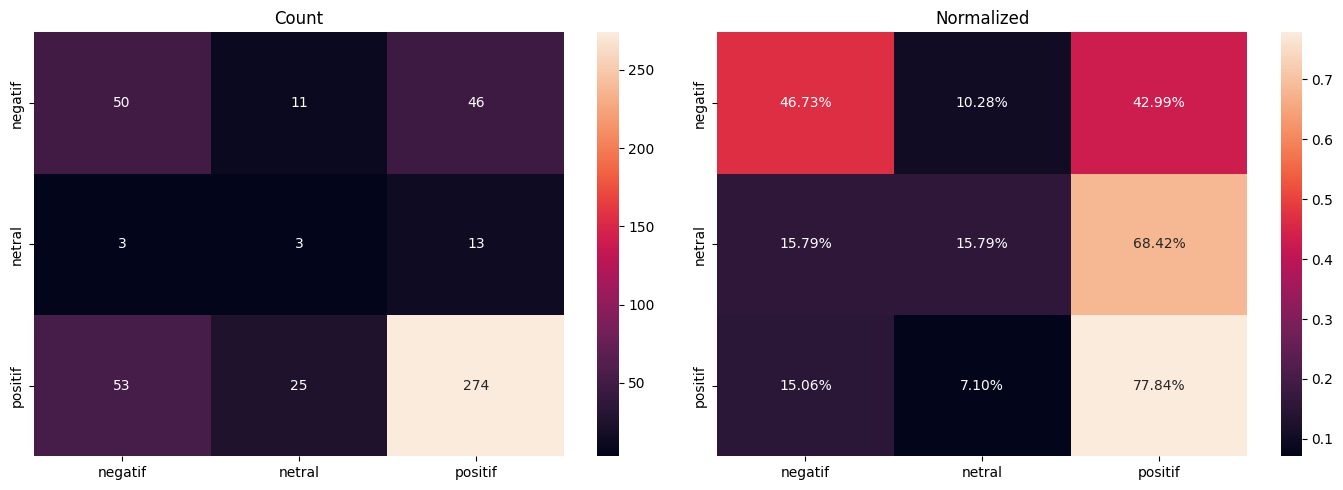


Total salah: 151 dari 478


In [ ]:
# Load data

df = pd.read_csv('ulasan_bersih.csv')
df = df.dropna(subset=['clean_text', 'label'])
df = df[df['clean_text'].astype(str).str.strip() != ''].reset_index(drop=True)

X = df['clean_text'].values
y = df['label'].values
labels = ['negatif', 'netral', 'positif']


# Pipeline model

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 1),
        max_features=3000,
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', LogisticRegression(
        C=0.1,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])


# Kumpulin prediksi dari 5-fold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []
idx_all = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    idx_all.extend(test_idx)

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)


# Hasil metrik

print("="*55)
print("PRECISION, RECALL, F1")
print("="*55)
print(classification_report(y_true_all, y_pred_all, target_names=labels))


# Confusion matrix

cm = confusion_matrix(y_true_all, y_pred_all, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Count')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.2%',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Normalized')

plt.tight_layout()
plt.show()


# Simpan hasil prediksi

df_pred = pd.DataFrame({
    'idx_asli': idx_all,
    'label_prediksi': y_pred_all
}).sort_values('idx_asli').reset_index(drop=True)

df_full = df.copy()
df_full['label_prediksi'] = df_pred['label_prediksi']

df_full.to_csv('hasil_prediksi.csv', index=False)


# Error

salah = df_full[df_full['label'] != df_full['label_prediksi']]
print(f"\nTotal salah: {len(salah)} dari {len(df_full)}")

Total prediksi salah: 151
Ambil 50 sampel

Sampel: 48

Ringkasan error
lainnya: 17 (35.4%)
pendek: 15 (31.2%)
netral_ambigu: 8 (16.7%)
sarkasme: 7 (14.6%)
domain_game: 1 (2.1%)


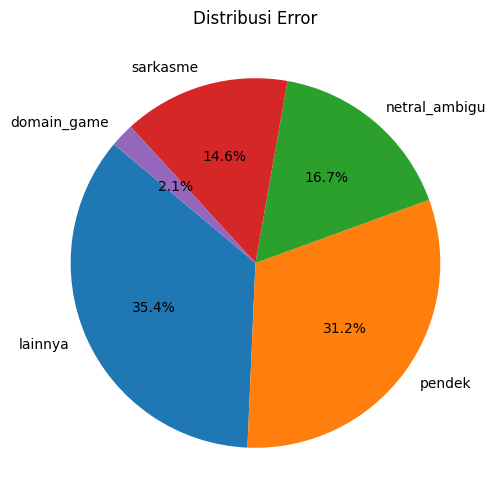

Saved


In [ ]:
# Load hasil prediksi

df = pd.read_csv('hasil_prediksi.csv')

df_salah = df[df['label'] != df['label_prediksi']].copy()
df_salah = df_salah.reset_index(drop=True)

print(f"Total prediksi salah: {len(df_salah)}")
print(f"Ambil 50 sampel\n")


# Ambil 50 sampel

df_sample = df_salah.groupby(['label', 'label_prediksi'], group_keys=False).apply(
    lambda g: g.sample(min(len(g), max(1, int(50 * len(g) / len(df_salah)))),
                       random_state=42)
).head(50).reset_index(drop=True)

print(f"Sampel: {len(df_sample)}")


# Kategori error

def tebak_kategori_error(row):
    teks_clean = str(row.get('clean_text', '')).lower()
    aktual = row['label']
    prediksi = row['label_prediksi']

    if any(k in teks_clean for k in ['tapi', 'cuman', 'cuma', 'sayangnya', 'kurang', 'meski']):
        return 'sarkasme'

    if len(teks_clean.split()) <= 3:
        return 'pendek'

    if aktual == 'netral' or prediksi == 'netral':
        return 'netral_ambigu'

    if any(k in teks_clean for k in ['bos', 'darah', 'nyerang', 'karakter', 'level', 'dev']):
        return 'domain_game'

    return 'lainnya'

df_sample['kategori_error'] = df_sample.apply(tebak_kategori_error, axis=1)


# Ringkasan

kategori_counts = df_sample['kategori_error'].value_counts()

print("\nRingkasan error")
for kat, cnt in kategori_counts.items():
    print(f"{kat}: {cnt} ({cnt/len(df_sample)*100:.1f}%)")


# Visualisasi

plt.figure(figsize=(8, 6))
plt.pie(kategori_counts, labels=kategori_counts.index,
        autopct='%1.1f%%', startangle=140)
plt.title('Distribusi Error')
plt.show()


# Simpan

df_sample[['clean_text', 'label', 'label_prediksi', 'kategori_error']] \
    .to_csv('error_analysis_50_sampel.csv', index=False)

print("Saved")

In [ ]:
# Load model & preprocessing

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

kamus_slang = {
    'yg':'yang','dgn':'dengan','gak':'tidak','ga':'tidak','gk':'tidak',
    'ngga':'tidak','nggak':'tidak','tp':'tapi','bgt':'banget','jg':'juga',
    'jd':'jadi','sdh':'sudah','udh':'sudah','udah':'sudah','blm':'belum',
    'emg':'memang','emang':'memang','gw':'saya','gue':'saya','lg':'lagi',
    'bs':'bisa','aja':'saja','sih':'','deh':'','dong':'','nih':'','lah':'',
    'ndk':'tidak','ndak':'tidak','donlod':'download','gem':'game','gim':'game',
    'mantap':'bagus','keren':'bagus','wkwk':'','haha':'','hehe':'',
}

stopword_id = set(stopwords.words('indonesian'))
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess(teks):
    teks = str(teks)
    teks = teks.encode('ascii', 'ignore').decode('ascii')
    teks = re.sub(r'http\S+|www\.\S+', '', teks)
    teks = re.sub(r'@\w+|#\w+', '', teks)
    teks = teks.lower()
    teks = re.sub(r'\d+', '', teks)
    teks = re.sub(r'(.)\1{2,}', r'\1', teks)
    teks = re.sub(r'[^\w\s]', ' ', teks)
    teks = re.sub(r'_', ' ', teks)

    kata = teks.split()
    kata = [kamus_slang.get(k, k) for k in kata]
    teks = ' '.join(w for w in kata if w)

    teks = re.sub(r'\s+', ' ', teks).strip()

    tokens = word_tokenize(teks)
    tokens = [t for t in tokens if t not in stopword_id and len(t) > 1]
    tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)

model = joblib.load('model_best.pkl')


def prediksi(teks_list):
    teks_clean = [preprocess(t) for t in teks_list]
    return model.predict(teks_clean)


# MFT

print("=== MFT ===")

mft_cases = [
    ("game ini sangat seru dan bagus sekali", "positif"),
    ("game ini sangat jelek dan penuh iklan", "negatif"),
    ("biasa saja, tidak terlalu bagus tidak terlalu jelek", "netral"),
]

pred_mft = prediksi([c[0] for c in mft_cases])

for (teks, exp), pred in zip(mft_cases, pred_mft):
    status = "PASS" if pred == exp else "FAIL"
    print(f"{status} | exp: {exp} pred: {pred}")


# INV

print("\n=== INV ===")

inv_cases = [
    ("game ini gak bagus", "game ini tidak bagus"),
    ("seru bgt gamenya", "seru banget gamenya"),
    ("game ini bagus dan seru", "game ini seru dan bagus"),
]

for a, b in inv_cases:
    pa, pb = prediksi([a])[0], prediksi([b])[0]
    status = "INVARIANT" if pa == pb else "BERUBAH"
    print(f"{status}")
    print(f"A: {pa} | B: {pb}")


# Simpan

pd.DataFrame({
    'teks': [c[0] for c in mft_cases],
    'expected': [c[1] for c in mft_cases],
    'pred': pred_mft
}).to_csv('checklist_mft.csv', index=False)

print("Saved")

=== MFT ===
PASS | exp: positif pred: positif
PASS | exp: negatif pred: negatif
FAIL | exp: netral pred: negatif

=== INV ===
INVARIANT
A: positif | B: positif
INVARIANT
A: positif | B: positif
INVARIANT
A: positif | B: positif
Saved
